In [1]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from John_Jellicoe import algoritmo_JJ
from backtracking import resolver_tablero

from auxiliares import generar_caso_de_prueba, print_tablero

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [2]:
import time

x = np.linspace(10, 300, 15).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': []
}
worst_ratio =1
worst_parameters = None
for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': []
    }

    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generar_caso_de_prueba(offset_n_m, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
        optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
        if optimality_ratio < worst_ratio:
            worst_ratio = optimality_ratio
            worst_parameters = (n, m, ship_lengths, original_row, original_col)
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))

print(f"Peor ratio: {worst_ratio} para {worst_parameters}")


Tamaño 10x10 ...
Tamaño 30x31 ...
Tamaño 51x51 ...
Tamaño 72x71 ...
Tamaño 92x91 ...
Tamaño 113x113 ...
Tamaño 134x134 ...
Tamaño 155x156 ...
Tamaño 175x176 ...
Tamaño 196x197 ...
Tamaño 217x218 ...
Tamaño 237x237 ...
Tamaño 258x257 ...
Tamaño 279x279 ...
Tamaño 300x301 ...
Peor ratio: 0.7099041533546326 para (np.int64(279), np.int64(279), [274, 254, 234, 200, 176, 164, 123, 83, 36, 21], [np.int64(202), np.int64(8), np.int64(126), np.int64(45), np.int64(159), np.int64(230), np.int64(193), np.int64(125), np.int64(234), np.int64(127), np.int64(180), np.int64(274), np.int64(133), np.int64(62), np.int64(165), np.int64(214), np.int64(141), np.int64(228), np.int64(60), np.int64(10), np.int64(240), np.int64(40), np.int64(27), np.int64(112), np.int64(242), np.int64(158), np.int64(147), np.int64(223), np.int64(195), np.int64(93), np.int64(38), np.int64(75), np.int64(79), np.int64(181), np.int64(37), np.int64(91), np.int64(246), np.int64(258), np.int64(75), np.int64(130), np.int64(143), np.int64

In [3]:
board = np.zeros((n, m), dtype=int)

print_tablero(board, worst_parameters[2], worst_parameters[3])

        202    8  126   45  159  230  193  125  234  127  180  274  133   62  165  214  141  228   60   10  240   40   27  112  242  158  147  223  195   93   38   75   79  181   37   91  246  258   75  130  143  130  230   80  183  102  118   28  221   59  213  150  180  113  152   95  276  119  221   78   21   82   55  153   25  225   28  166   83   83   29  228  260   66  238  184  103   48   82  244   35  190  264  172  166  157   77  159  263  173  166  229  224  109   44  173  279  170  218   91   30  191   15  167  154   91   21  101   29   79    7  138   81   21  221  242   50  238  211  268  207  117  105   62  120  273  183   47   56  203  105   25  273  223   40   56  208   14   82   78  212  267  266  234  256    7  126   31  111    6  277  141  140   93  236   64  153  195  104  211  106   32  254  109  108   38  107  246  206  181   85  146  130  146   23  203   60  208  204   41  111   80  272  107   15   93   81   92  231  254  232  128  193  250   47  106   51  272  16

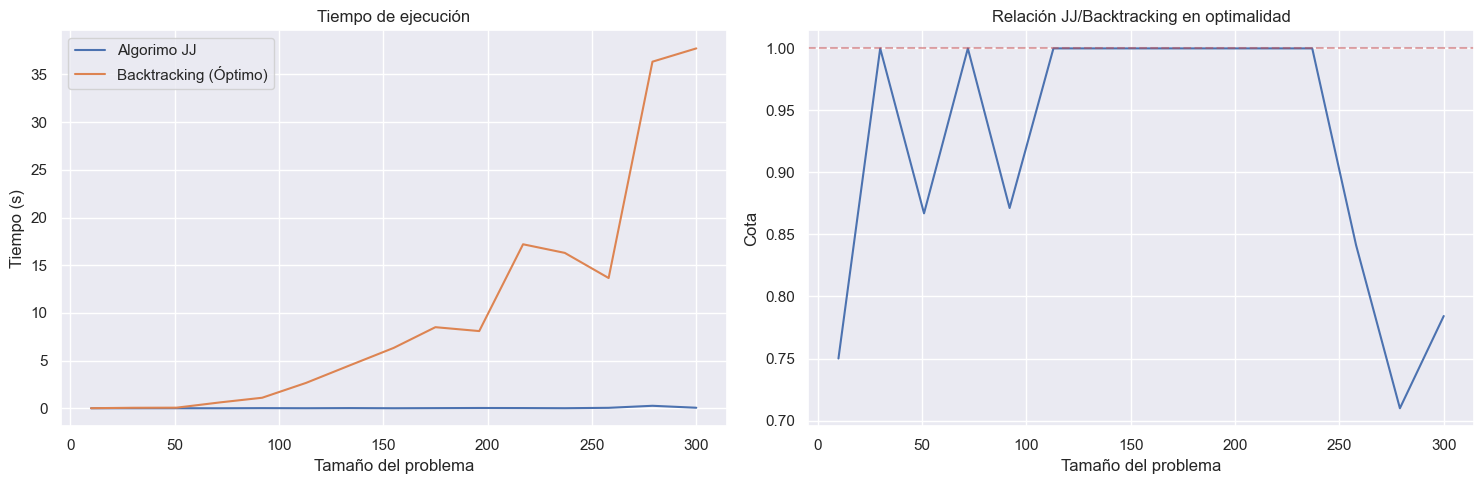

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results['size'], results['jj_time'], label='Algorimo JJ')
ax1.plot(results['size'], results['backtrack_time'], label='Backtracking (Óptimo)')
ax1.set_title('Tiempo de ejecución')
ax1.set_xlabel('Tamaño del problema')
ax1.set_ylabel('Tiempo (s)')
ax1.legend()
# ax1.set_yscale('log')

# Plot optimality ratio
ax2.plot(results['size'], results['optimality_ratio'])
ax2.set_title('Relación JJ/Backtracking en optimalidad')
ax2.set_xlabel('Tamaño del problema')
ax2.set_ylabel('Cota')
ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
